NETFLIX DATASET

First 5 Rows:
  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans              NaN   
4      s5  TV Show           Kota Factory              NaN   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   
3                                                NaN            NaN   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

           date_added  release_year rating   duration  \
0  September 25, 2021          2020  PG-13     90 min   
1  September 24, 2021          2021  TV-MA  2 Seasons  

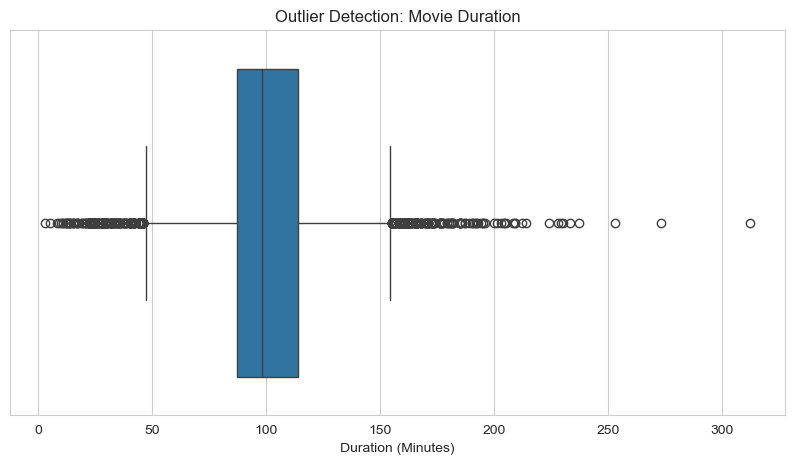

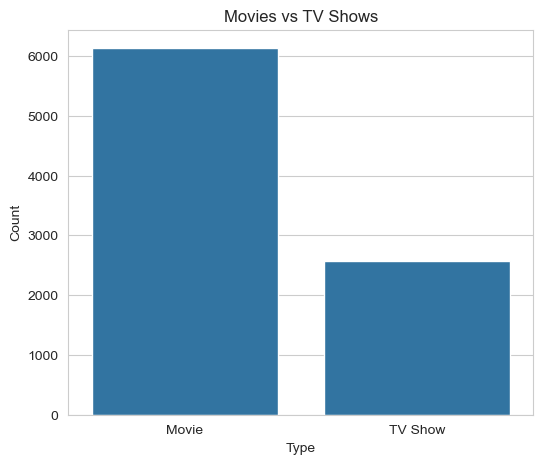

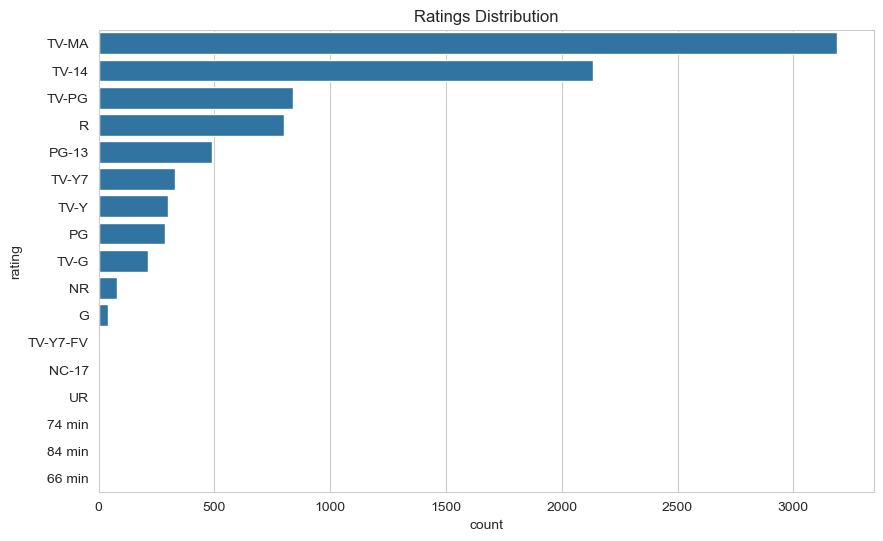

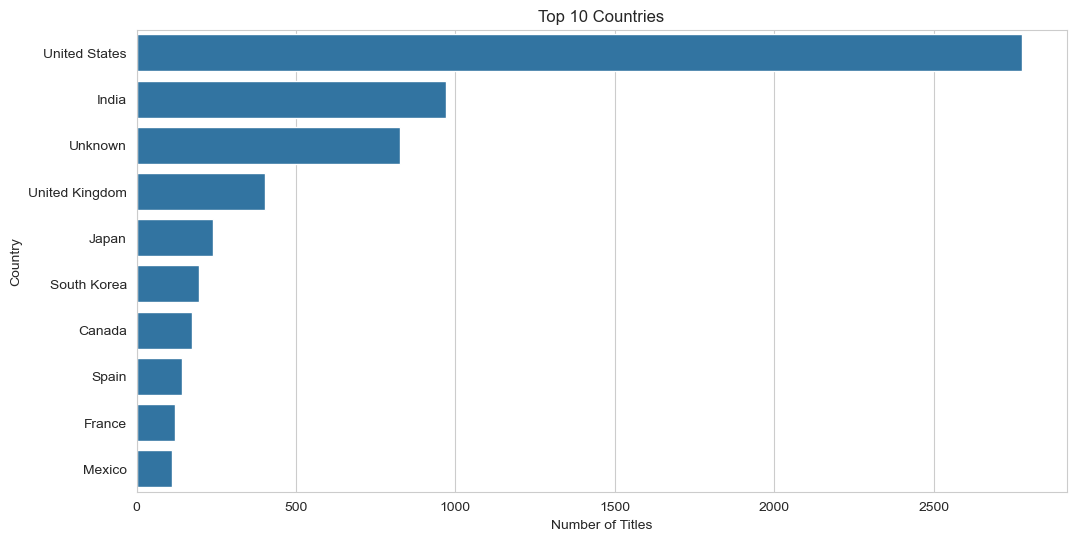

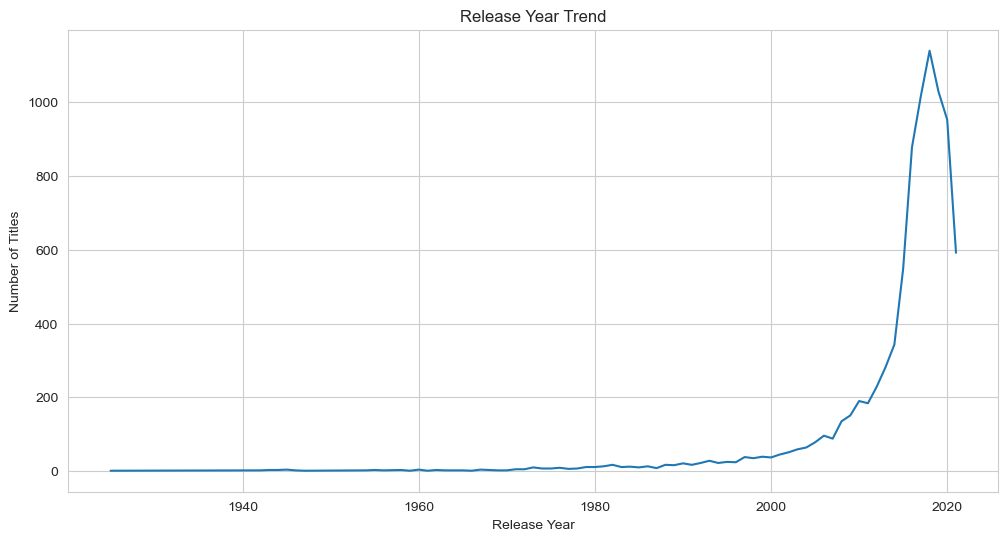

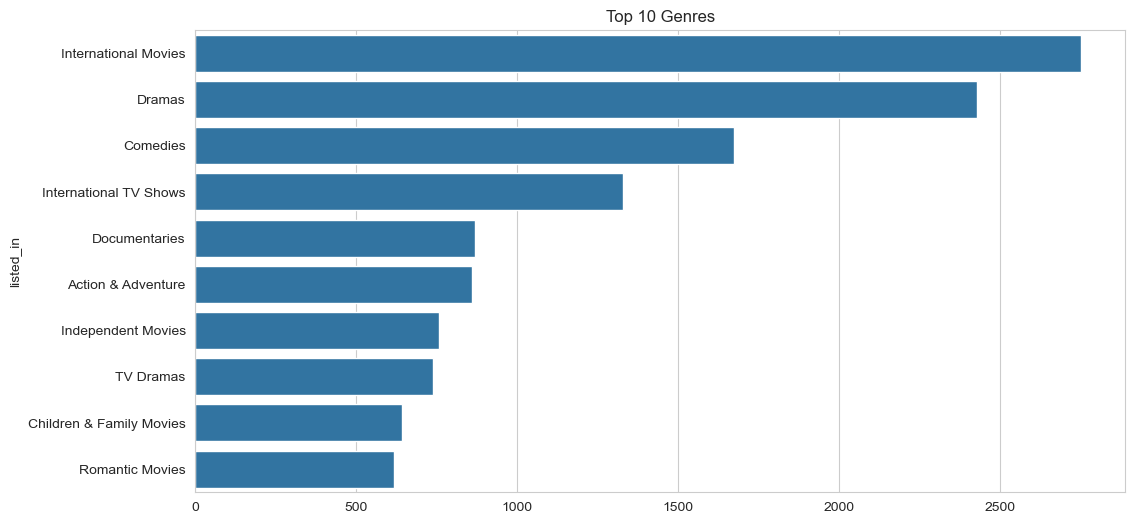

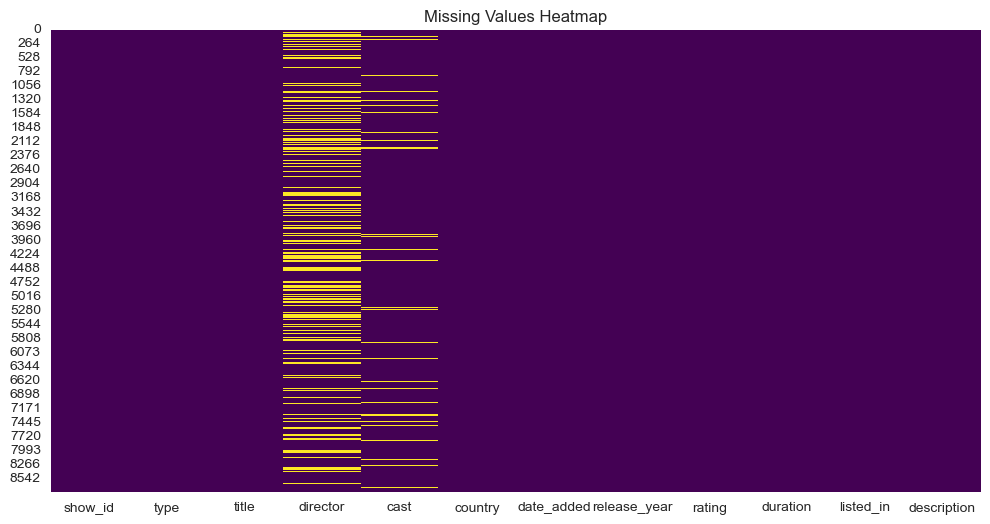

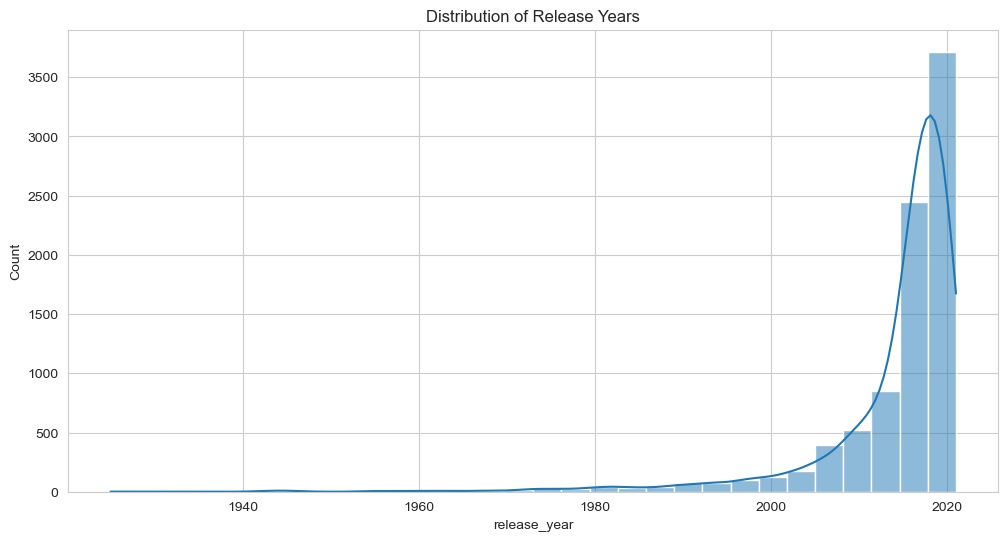

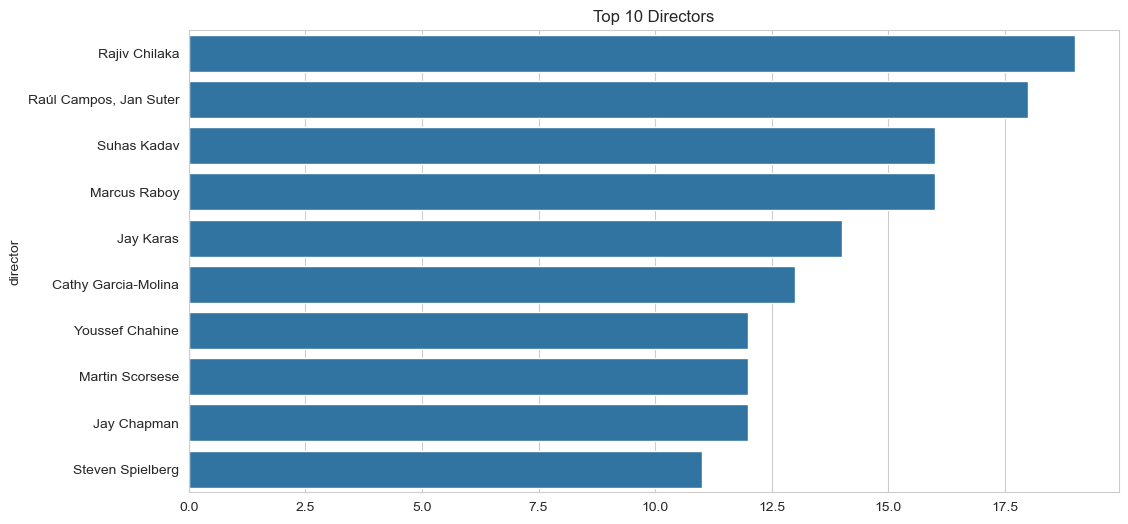

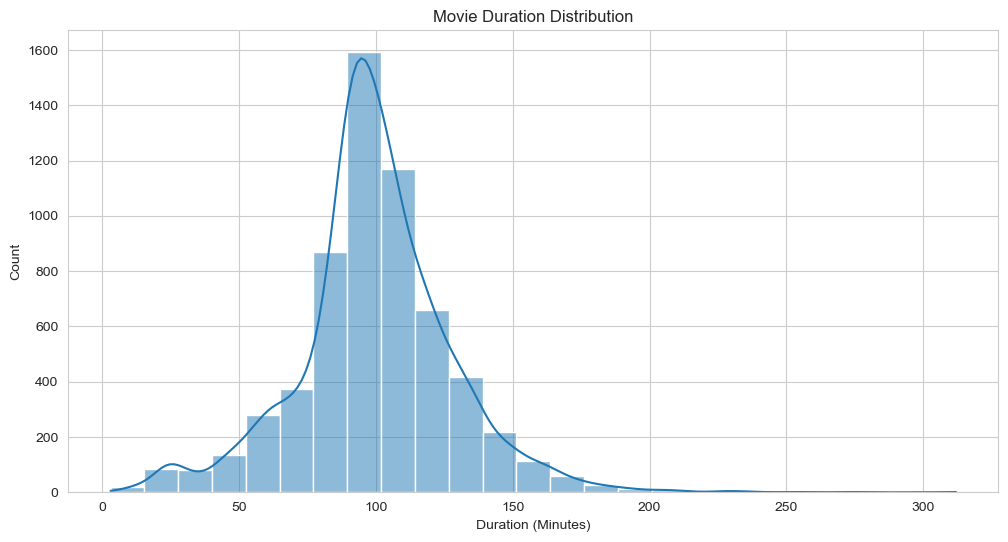

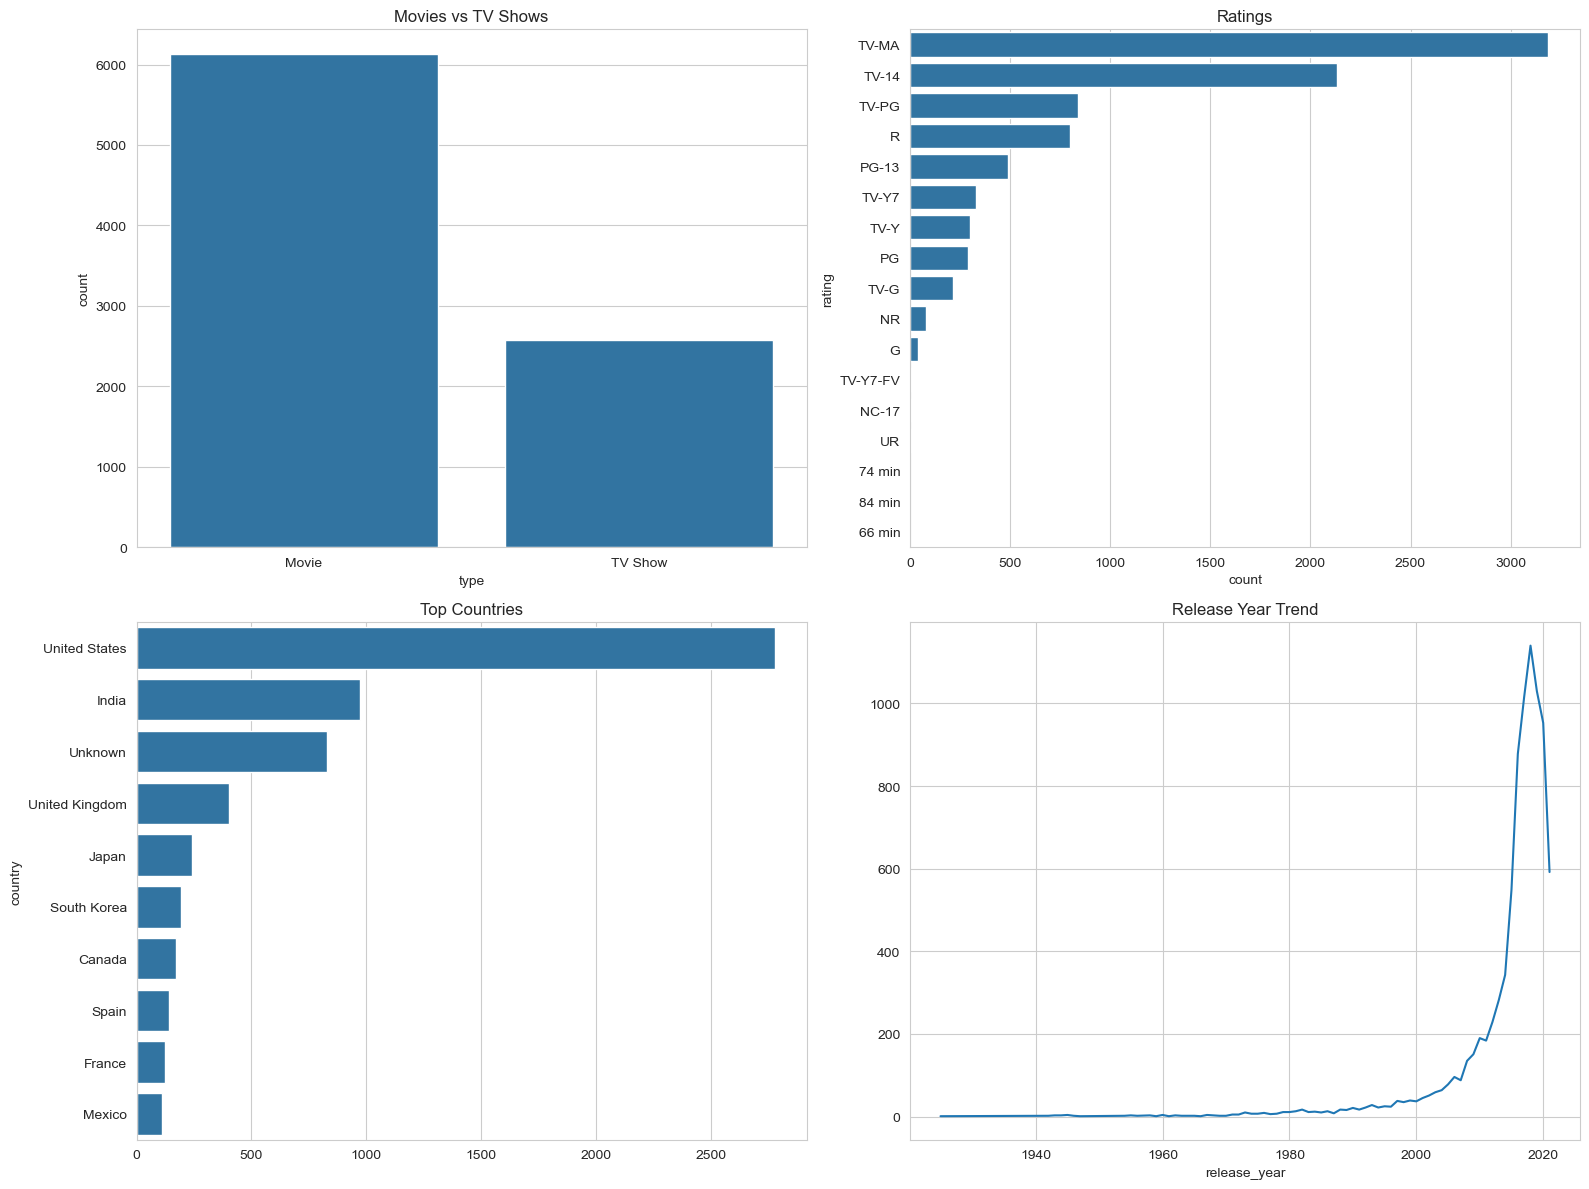


PROJECT INSIGHTS
• Movies are more common than TV Shows.
• The United States contributes the highest number of Netflix titles.
• TV-MA is the most common content rating.
• Drama and International Movies are among the most popular genres.
• Netflix released a large amount of content after 2015.
• Missing values and duplicate records were successfully handled.

Project Completed Successfully!

CONCLUSION

This project cleaned and analyzed the Netflix Titles dataset using Python.
Missing values were handled, duplicate records were removed, and multiple
visualizations were created using Pandas, Matplotlib, and Seaborn.
The analysis provides useful insights into Netflix content based on type,
country, genre, ratings, release year, and duration.



In [1]:
# ===============================================
# DATA CLEANING & VISUALIZATION PROJECT
# Netflix Titles Dataset
# ===============================================

# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Settings
pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")

# Load Dataset
df = pd.read_csv("netflix_titles.csv")

# ==========================
# BASIC INFORMATION
# ==========================
print("="*70)
print("NETFLIX DATASET")
print("="*70)

print("\nFirst 5 Rows:")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

print("\nStatistical Summary:")
print(df.describe(include="all"))

# ==========================
# MISSING VALUES
# ==========================
print("\nMissing Values Before Cleaning:")
print(df.isnull().sum())

# ==========================
# DUPLICATES
# ==========================
duplicates = df.duplicated().sum()
print("\nDuplicate Rows:", duplicates)

df.drop_duplicates(inplace=True)

# ==========================
# HANDLE MISSING VALUES
# ==========================

if "country" in df.columns:
    df["country"] = df["country"].fillna("Unknown")

if "rating" in df.columns:
    df["rating"] = df["rating"].fillna(df["rating"].mode()[0])

# ADD THESE TWO LINES
if "duration" in df.columns:
    df["duration"] = df["duration"].fillna(df["duration"].mode()[0])

# Convert date safely
if "date_added" in df.columns:
    df["date_added"] = pd.to_datetime(
        df["date_added"],
        errors="coerce"
    )

    df.dropna(subset=["date_added"], inplace=True)

print("\nMissing Values After Cleaning:")
print(df.isnull().sum())
# ==========================
# OUTLIER DETECTION
# ==========================

movies = df[df["type"] == "Movie"].copy()

movies["duration"] = movies["duration"].str.replace(" min", "", regex=False)
movies["duration"] = pd.to_numeric(movies["duration"], errors="coerce")

plt.figure(figsize=(10,5))
sns.boxplot(x=movies["duration"])

plt.title("Outlier Detection: Movie Duration")
plt.xlabel("Duration (Minutes)")

plt.show()

# ==========================
# MOVIES VS TV SHOWS
# ==========================
plt.figure(figsize=(6,5))
sns.countplot(data=df,x="type")
plt.title("Movies vs TV Shows")
plt.xlabel("Type")
plt.ylabel("Count")
plt.show()

# ==========================
# RATINGS
# ==========================
plt.figure(figsize=(10,6))
sns.countplot(
    y="rating",
    data=df,
    order=df["rating"].value_counts().index
)
plt.title("Ratings Distribution")
plt.show()

# ==========================
# TOP COUNTRIES
# ==========================
top_country = df["country"].value_counts().head(10)

plt.figure(figsize=(12,6))
sns.barplot(
    x=top_country.values,
    y=top_country.index
)

plt.title("Top 10 Countries")
plt.xlabel("Number of Titles")
plt.ylabel("Country")
plt.show()

# ==========================
# RELEASE YEAR TREND
# ==========================
plt.figure(figsize=(12,6))

df["release_year"].value_counts().sort_index().plot()

plt.title("Release Year Trend")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
plt.show()

# ==========================
# TOP GENRES
# ==========================
genre = df["listed_in"].str.split(", ").explode()

top_genres = genre.value_counts().head(10)

plt.figure(figsize=(12,6))
sns.barplot(
    x=top_genres.values,
    y=top_genres.index
)

plt.title("Top 10 Genres")
plt.show()

# ==========================
# MISSING VALUE HEATMAP
# ==========================
plt.figure(figsize=(12,6))
sns.heatmap(df.isnull(),cbar=False,cmap="viridis")
plt.title("Missing Values Heatmap")
plt.show()

# ==========================
# RELEASE YEAR DISTRIBUTION
# ==========================
plt.figure(figsize=(12,6))
sns.histplot(
    df["release_year"],
    bins=30,
    kde=True
)

plt.title("Distribution of Release Years")
plt.show()

# ==========================
# TOP DIRECTORS
# ==========================
top_directors = (
    df[df["director"]!="Unknown"]["director"]
    .value_counts()
    .head(10)
)

plt.figure(figsize=(12,6))
sns.barplot(
    x=top_directors.values,
    y=top_directors.index
)

plt.title("Top 10 Directors")
plt.show()

# ==========================
# MOVIE DURATION
# ==========================
movies = df[df["type"]=="Movie"].copy()

movies["duration"] = (
    movies["duration"]
    .str.replace(" min","",regex=False)
)

movies["duration"] = pd.to_numeric(
    movies["duration"],
    errors="coerce"
)

plt.figure(figsize=(12,6))

sns.histplot(
    movies["duration"].dropna(),
    bins=25,
    kde=True
)

plt.title("Movie Duration Distribution")
plt.xlabel("Duration (Minutes)")
plt.show()

# ==========================
# DASHBOARD
# ==========================
fig,axes=plt.subplots(2,2,figsize=(16,12))
sns.countplot(
    data=df,
    x="type",
    ax=axes[0,0]
)
axes[0,0].set_title("Movies vs TV Shows")

sns.countplot(
    y="rating",
    data=df,
    order=df["rating"].value_counts().index,
    ax=axes[0,1]
)
axes[0,1].set_title("Ratings")

sns.barplot(
    x=top_country.values,
    y=top_country.index,
    ax=axes[1,0]
)
axes[1,0].set_title("Top Countries")

df["release_year"].value_counts().sort_index().plot(ax=axes[1,1])
axes[1,1].set_title("Release Year Trend")

plt.tight_layout()
plt.show()

# ==========================
# FINAL INSIGHTS
# ==========================
print("\n"+"="*70)
print("PROJECT INSIGHTS")
print("="*70)

print("• Movies are more common than TV Shows.")
print("• The United States contributes the highest number of Netflix titles.")
print("• TV-MA is the most common content rating.")
print("• Drama and International Movies are among the most popular genres.")
print("• Netflix released a large amount of content after 2015.")
print("• Missing values and duplicate records were successfully handled.")

print("\nProject Completed Successfully!")

print("\n"+"="*70)
print("CONCLUSION")
print("="*70)

print("""
This project cleaned and analyzed the Netflix Titles dataset using Python.
Missing values were handled, duplicate records were removed, and multiple
visualizations were created using Pandas, Matplotlib, and Seaborn.
The analysis provides useful insights into Netflix content based on type,
country, genre, ratings, release year, and duration.
""")